In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score , classification_report ,confusion_matrix

In [2]:
df = pd.read_csv("train.csv")

In [3]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
df.describe()
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [5]:
df = df.drop(columns=['Married','Loan_ID','Dependents'])

In [6]:
df['Gender']= df['Gender'].fillna(df['Gender'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

In [7]:
df.isnull().sum()

Gender               0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [8]:
from sklearn.preprocessing import LabelEncoder
le_gender = LabelEncoder()
df['Gender'] = le_gender.fit_transform(df['Gender'])

le_education = LabelEncoder()
df['Education'] = le_education.fit_transform(df['Education'])

le_Self_Employed = LabelEncoder()
df['Self_Employed'] = le_Self_Employed.fit_transform(df['Self_Employed'])

le_Property_Area = LabelEncoder()
df['Property_Area'] = le_Property_Area.fit_transform(df['Property_Area'])

le_Loan_Status = LabelEncoder()
df['Loan_Status'] = le_Loan_Status.fit_transform(df['Loan_Status'])

In [9]:
X = df.drop(columns=['Loan_Status'])
y = df['Loan_Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [10]:
model = AdaBoostClassifier(random_state=42)
model.fit(X_train, y_train)

c:\Users\Srinith Samala\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoostClassifier(random_state=42)

In [11]:
print(model.estimator_)

DecisionTreeClassifier(max_depth=1)


In [12]:
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Train Score:", model.score(X_train, y_train))
print("Test Score:", model.score(X_test, y_test))

[[19 24]
 [ 3 77]]
0.7804878048780488
              precision    recall  f1-score   support

           0       0.86      0.44      0.58        43
           1       0.76      0.96      0.85        80

    accuracy                           0.78       123
   macro avg       0.81      0.70      0.72       123
weighted avg       0.80      0.78      0.76       123

Train Score: 0.8492871690427699
Test Score: 0.7804878048780488


c:\Users\Srinith Samala\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\Srinith Samala\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\Srinith Samala\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


c:\Users\Srinith Samala\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\Srinith Samala\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\Srinith Samala\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\Srinith Samala\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The

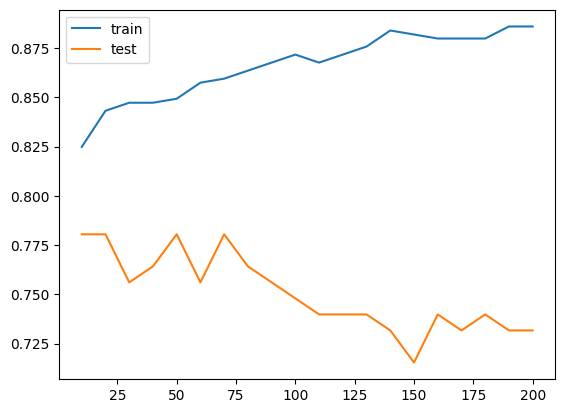

In [13]:
train_scores, test_scores = [] ,[]
n_ranges = range(10,201,10)

for n in n_ranges:
    m = AdaBoostClassifier(n_estimators=n, random_state= 42)
    m.fit(X_train,y_train)
    train_scores.append(m.score(X_train,y_train))
    test_scores.append(m.score(X_test, y_test))

plt.plot(n_ranges,train_scores,label = "train")
plt.plot(n_ranges,test_scores,label = "test")
plt.legend()
plt.show()

In [14]:
import numpy as np 
best_index = np.argmax(test_scores)
best_n = list(n_ranges)[best_index]
print("Biest of estimator:",best_n)

model = AdaBoostClassifier(n_estimators=best_n,random_state = 42)
model.fit(X_train,y_train)



Biest of estimator: 10


c:\Users\Srinith Samala\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoostClassifier(n_estimators=10, random_state=42)

In [15]:
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Train Score:", model.score(X_train, y_train))
print("Test Score:", model.score(X_test, y_test))

[[18 25]
 [ 2 78]]
0.7804878048780488
              precision    recall  f1-score   support

           0       0.90      0.42      0.57        43
           1       0.76      0.97      0.85        80

    accuracy                           0.78       123
   macro avg       0.83      0.70      0.71       123
weighted avg       0.81      0.78      0.75       123

Train Score: 0.824847250509165
Test Score: 0.7804878048780488


In [16]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)
print(importance_df)

             Feature  Importance
5         LoanAmount         0.3
8      Property_Area         0.2
4  CoapplicantIncome         0.2
6   Loan_Amount_Term         0.1
3    ApplicantIncome         0.1
7     Credit_History         0.1
0             Gender         0.0
1          Education         0.0
2      Self_Employed         0.0


In [17]:
print(model.algorithm)

SAMME.R
